<a href="https://colab.research.google.com/github/axelmartinezportillo/Parcial4-Axel-Martinez-25-2318-2022/blob/main/Notebook/Parcial4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Cargar los datos
df_corr = pd.read_csv('https://raw.githubusercontent.com/axelmartinezportillo/Parcial4-Axel-Martinez-25-2318-2022/refs/heads/main/Data/clave_D_correlacion.csv')

In [3]:
# 2. Revisión e inspección de calidad inicial
print("--- Inspección Inicial de Datos ---")
print(f"Cantidad total de registros: {df_corr.shape[0]}")
print(f"Cantidad de columnas: {df_corr.shape[1]}")
print(f"Valores nulos encontrados por columna:\n{df_corr.isnull().sum()}")
print(f"\nCantidad de registros duplicados: {df_corr.duplicated().sum()}")

--- Inspección Inicial de Datos ---
Cantidad total de registros: 236
Cantidad de columnas: 10
Valores nulos encontrados por columna:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64

Cantidad de registros duplicados: 1


In [5]:
# 1. Eliminar registros duplicados y crear una copia explícita
df_corr_limpio = df_corr.drop_duplicates().copy()

# 2. Imputar (rellenar) los valores nulos con la mediana usando .loc
columnas_con_nulos = ['ticket_promedio', 'satisfaccion', 'tiempo_respuesta']
for col in columnas_con_nulos:
    mediana = df_corr_limpio[col].median()
    df_corr_limpio.loc[:, col] = df_corr_limpio[col].fillna(mediana)

# 3. Verificación final de la limpieza
print("--- Verificación Post-Limpieza ---")
print(f"Cantidad de registros final: {df_corr_limpio.shape[0]}")
print(f"Total de nulos en el dataset: {df_corr_limpio.isnull().sum().sum()}")
print(f"Total de duplicados: {df_corr_limpio.duplicated().sum()}")

--- Verificación Post-Limpieza ---
Cantidad de registros final: 235
Total de nulos en el dataset: 0
Total de duplicados: 0


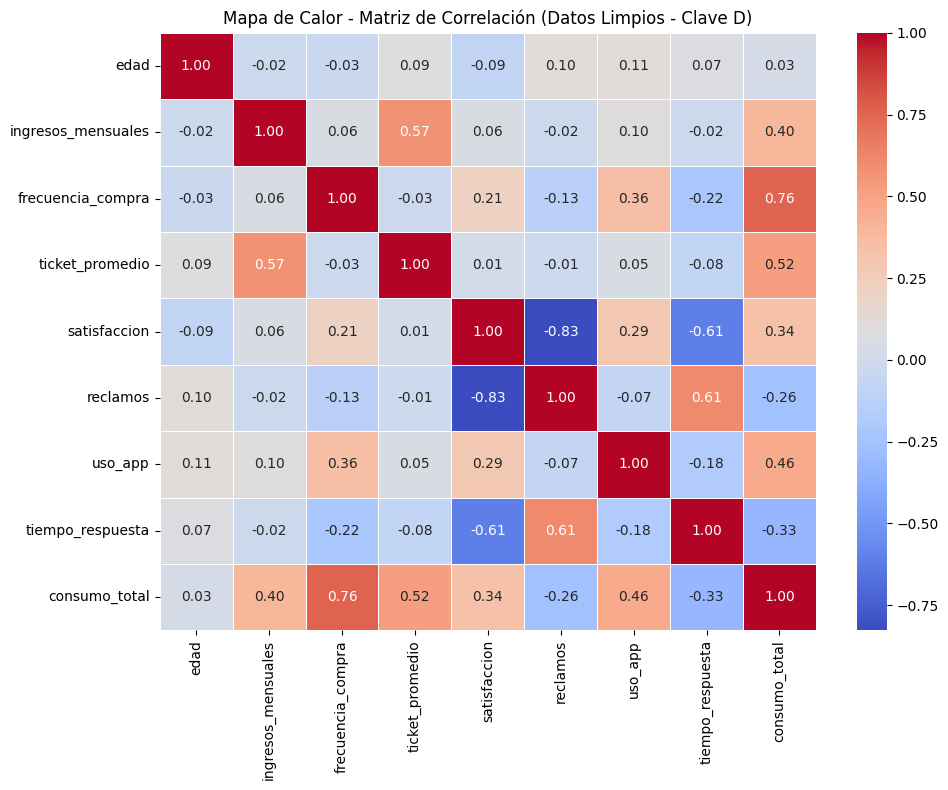

In [8]:
# Calcular la matriz de correlación de los datos limpios sin el cliente_id
matriz_corr = df_corr_limpio.drop(columns=['cliente_id']).corr()

# Dibujar el mapa de calor (Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor - Matriz de Correlación (Datos Limpios - Clave D)')
plt.tight_layout()
plt.show()

In [17]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Cargar el archivo directamente aquí para asegurar que exista en memoria
df_asoc_final = pd.read_csv('https://raw.githubusercontent.com/axelmartinezportillo/Parcial4-Axel-Martinez-25-2318-2022/refs/heads/main/Data/clave_D_asociacion.csv')

In [18]:
# 2. Control de calidad rápido para tu Word
print("--- CONTROL DE CALIDAD (ASOCIACIÓN) ---")
print(f"Total de registros cargados: {df_asoc.shape[0]}")
print(f"Valores nulos por columna:\n{df_asoc.isnull().sum()}")
print(f"Cantidad de duplicados: {df_asoc.duplicated().sum()}")

--- CONTROL DE CALIDAD (ASOCIACIÓN) ---
Total de registros cargados: 607
Valores nulos por columna:
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64
Cantidad de duplicados: 1


In [19]:
# 2. Limpieza inmediata
df_limpio_asoc = df_asoc_final.drop_duplicates()

In [21]:
# 3. Crear la matriz de transacciones (Market Basket Analysis)
basket = (df_limpio_asoc.groupby(['transaccion_id', 'item'])['cantidad']
          .sum().unstack().reset_index().fillna(0)
          .set_index('transaccion_id'))

# 4. Convertir a valores booleanos (True/False)
basket_encoded = basket.applymap(lambda x: True if x > 0 else False)

# 5. Bajamos el soporte a 0.005 para que nos encuentre más combinaciones en los 607 registros
frequent_itemsets = apriori(basket_encoded, min_support=0.005, use_colnames=True)

# 6. Generar las Reglas de Asociación con Lift mínimo de 1.0
reglas = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# 7. Ordenar por las combinaciones más valiosas (Lift y Confianza)
reglas = reglas.sort_values(by=['lift', 'confidence'], ascending=[False, False])

# 8. Imprimir exactamente las 10 mejores reglas en pantalla
print("--- LAS 10 REGLAS DE ASOCIACIÓN MÁS RELEVANTES ---")
columnas_interes = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(reglas[columnas_interes].head(10).to_string(index=False))

--- LAS 10 REGLAS DE ASOCIACIÓN MÁS RELEVANTES ---
                               antecedents                              consequents  support  confidence  lift
            (Capuchino, Muffin, Croissant)                    (Chocolate, Ensalada) 0.005556         1.0 180.0
                     (Chocolate, Ensalada)           (Capuchino, Muffin, Croissant) 0.005556         1.0 180.0
  (Combo_estudiante, Combo_tarde, Galleta)                         (Sirope, Panini) 0.005556         1.0 180.0
                          (Sirope, Panini) (Combo_estudiante, Combo_tarde, Galleta) 0.005556         1.0 180.0
      (Capuchino, Combo_oficina, Sandwich) (Chocolate, Combo_tarde, Cafe_americano) 0.005556         1.0 180.0
(Capuchino, Combo_oficina, Cafe_americano)       (Chocolate, Combo_tarde, Sandwich) 0.005556         1.0 180.0
  (Capuchino, Combo_tarde, Cafe_americano)     (Combo_oficina, Chocolate, Sandwich) 0.005556         1.0 180.0
    (Capuchino, Chocolate, Cafe_americano)   (Combo_oficina, 

In [22]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# 1. Cargar el dataset de agrupación
df_agrup_final = pd.read_csv('clave_D_agrupacion.csv')